# Capítulo 35 — Comparar distribuciones por grupos

## Mirar una variable numérica según categorías

En el capítulo anterior aprendimos a visualizar distribuciones de variables numéricas. Trabajamos con `total_bill` y `tip`, usando histogramas y boxplots para observar cómo se reparten sus valores. Ahora vamos a avanzar un paso más.

En lugar de mirar una variable numérica de manera general, vamos a compararla según distintos grupos o categorías.

Por ejemplo:

**¿los importes de las cuentas son parecidos en `Lunch` y en `Dinner`?**

**¿hay diferencias entre los días registrados en el dataset?**

**¿la distribución de las propinas cambia según alguna categoría?**

Para responder este tipo de preguntas vamos a combinar variables numéricas con variables categóricas.

En este capítulo vamos a usar principalmente:

- `total_bill`, como variable numérica;
- `time`, `day` y otras columnas categóricas para formar grupos.

## Cargar el dataset

Como en los capítulos anteriores, vamos a trabajar con el dataset `tips`.
Primero importamos las librerías necesarias y cargamos los datos.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


La salida muestra las primeras filas del dataset `tips`. Cada fila representa una cuenta registrada en un restaurante.

En capítulos anteriores ya analizamos algunas columnas por separado. Ahora vamos a combinar dos tipos de variables: una variable numérica, como `total_bill` y una variable categórica, como `time`, `day`, `sex` o `smoker`.

Esto nos permitirá comparar distribuciones entre grupos. Por ejemplo, podemos mirar si los importes de las cuentas se distribuyen de la misma manera en `Lunch` y en `Dinner`.

## Primera comparación: importe total según horario

Vamos a empezar comparando la columna `total_bill` según el horario de la cuenta.

Para eso usaremos la columna `time`, que distingue entre:

- `Lunch`;
- `Dinner`.

Antes de graficar, conviene calcular un resumen numérico por grupo.

Así podremos observar cuántas cuentas hay en cada horario y cuáles son los valores principales de `total_bill` para cada uno.

In [ ]:
resumen_time = df.groupby("time", observed=True)["total_bill"].agg(
    cantidad_cuentas="count",
    promedio="mean",
    mediana="median",
    minimo="min",
    maximo="max"
).round(2)

resumen_time

,cantidad_cuentas,promedio,mediana,minimo,maximo
time,,,,,
Lunch,68,17.17,15.96,7.51,43.11
Dinner,176,20.80,18.39,3.07,50.81


La tabla resume los importes de las cuentas según el horario. En `Lunch` hay 68 cuentas registradas, mientras que en `Dinner` hay 176. Esto indica que el dataset tiene muchos más registros de cena que de almuerzo.

También se observan diferencias en los importes:

- el promedio de `total_bill` en `Lunch` es 17.17;
- el promedio de `total_bill` en `Dinner` es 20.80;
- la mediana en `Lunch` es 15.96;
- la mediana en `Dinner` es 18.39.

En este dataset, las cuentas de `Dinner` tienden a tener importes más altos que las cuentas de `Lunch`.

Sin embargo, esta tabla todavía no nos muestra cómo se distribuyen los valores dentro de cada horario. Para eso vamos a usar un boxplot.

## Comparar distribuciones con boxplot

Un boxplot permite comparar una variable numérica entre distintos grupos.

En este caso vamos a usar:

- `time` en el eje horizontal;
- `total_bill` en el eje vertical.

Así podremos comparar la distribución de los importes entre `Lunch` y `Dinner`.

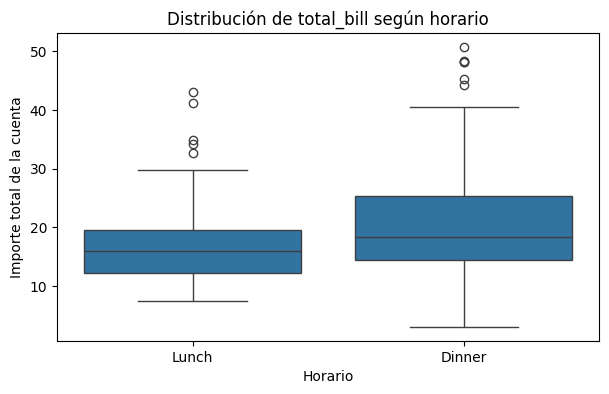

In [ ]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="time",
    y="total_bill"
)

plt.title("Distribución de total_bill según horario")
plt.xlabel("Horario")
plt.ylabel("Importe total de la cuenta")

plt.show()

El boxplot compara la distribución de los importes de las cuentas según el horario.

* En `Lunch`, la mediana se ubica alrededor de 15.96.
* En `Dinner`, la mediana es más alta, alrededor de 18.39.

También se observa que la caja de `Dinner` está algo más extendida. Esto indica que la mitad central de las cuentas de cena tiene una mayor dispersión que la mitad central de las cuentas de almuerzo.

Además, en ambos horarios aparecen posibles valores extremos hacia importes altos.

* En `Lunch` hay algunas cuentas por encima de 30 y 40.
* En `Dinner` aparecen varios valores altos, incluso cercanos a 50.

Esta comparación refuerza lo que vimos en la tabla: en este dataset, las cuentas de `Dinner` tienden a ser más altas que las de `Lunch`.

## Cuidado al comparar grupos

Cuando comparamos distribuciones entre grupos, no alcanza con mirar solamente qué grupo tiene valores más altos. También tenemos que observar cuántos datos hay en cada grupo.

En este caso, `Dinner` tiene 176 cuentas y `Lunch` tiene 68.

Eso significa que la comparación no está basada en la misma cantidad de registros. La diferencia no invalida el análisis, pero nos recuerda que siempre conviene mirar el tamaño de cada grupo antes de sacar conclusiones.

## Ver la cantidad de registros por grupo

Para reforzar esta idea, vamos a contar cuántas cuentas hay en cada horario. Ya vimos ese dato en la tabla de resumen, pero ahora lo vamos a visualizar con un gráfico de barras. La pregunta será:

**¿cuántas cuentas hay registradas en cada horario?**

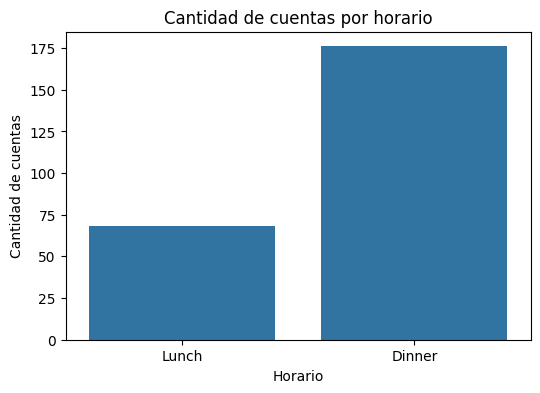

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="time"
)

plt.title("Cantidad de cuentas por horario")
plt.xlabel("Horario")
plt.ylabel("Cantidad de cuentas")

plt.show()

El gráfico muestra la cantidad de cuentas registradas en cada horario. Se observa que `Dinner` tiene muchas más cuentas que `Lunch`.

Esto coincide con la tabla anterior:

- `Lunch`: 68 cuentas;
- `Dinner`: 176 cuentas.

Este dato es importante porque nos ayuda a interpretar mejor la comparación de distribuciones.

Por ejemplo, en el boxplot de `Dinner` aparecen más valores altos y más posibles valores extremos. Eso puede estar relacionado, en parte, con que hay más registros de cena que de almuerzo.

Cuando un grupo tiene muchos más datos, también aumentan las chances de observar valores más variados o extremos. Por eso, al comparar grupos, conviene mirar siempre dos cosas:

* la forma de la distribución; y
* la cantidad de datos que sostiene cada grupo.

## Comparar importes según el día

Ahora vamos a hacer una comparación similar, pero usando la columna `day`.

La pregunta será:

**¿cómo se distribuyen los importes de las cuentas según el día?**

Para eso vamos a usar nuevamente un boxplot.

Como los días registrados pueden leerse siguiendo un orden temporal básico, vamos a definir el orden:

`Thur`, `Fri`, `Sat`, `Sun`

Esto nos permitirá leer el gráfico de manera más clara.

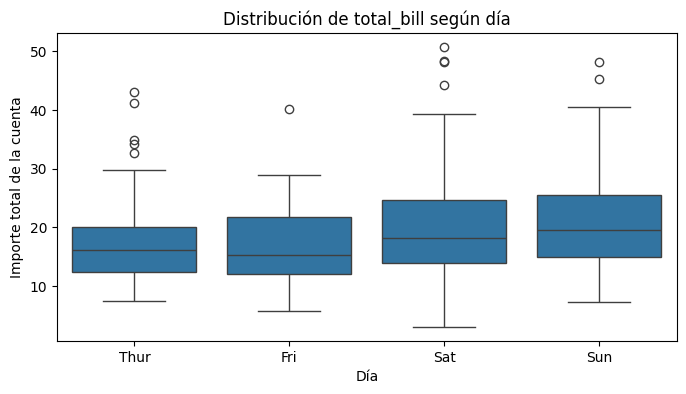

In [ ]:
orden_dias = ["Thur", "Fri", "Sat", "Sun"]

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="day",
    y="total_bill",
    order=orden_dias
)

plt.title("Distribución de total_bill según día")
plt.xlabel("Día")
plt.ylabel("Importe total de la cuenta")

plt.show()

El boxplot muestra la distribución de `total_bill` según el día. Podemos observar que las medianas no son iguales en todos los días.

`Thur` y `Fri` tienen medianas más bajas, mientras que `Sat` y `Sun` muestran medianas algo más altas.

También se ve que `Sat` y `Sun` tienen cajas más extendidas. Esto indica una mayor dispersión en la mitad central de los importes.

En varios días aparecen posibles valores extremos hacia importes altos.

Por ejemplo, `Thur` tiene algunos valores por encima de 30 y 40, `Sat` tiene valores cercanos a 50, y `Sun` también muestra algunos importes altos.

La lectura general sugiere que, en este dataset, las cuentas de fin de semana tienden a tener importes más altos que las de `Thur` y `Fri`. Pero antes de sacar conclusiones, conviene mirar cuántas cuentas hay registradas en cada día.

## Cantidad de registros por día

Como vimos con `Lunch` y `Dinner`, la cantidad de registros puede influir en la interpretación.

Si un día tiene muchas más cuentas que otro, es más probable que aparezcan valores variados o extremos.

Por eso vamos a visualizar cuántas cuentas hay en cada día.

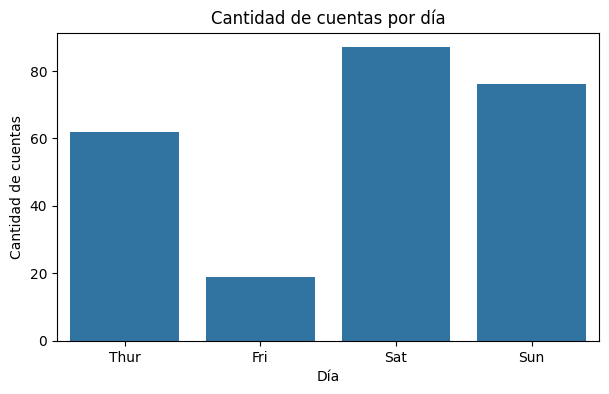

In [ ]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="day",
    order=orden_dias
)

plt.title("Cantidad de cuentas por día")
plt.xlabel("Día")
plt.ylabel("Cantidad de cuentas")

plt.show()

El gráfico muestra cuántas cuentas hay registradas en cada día.

La cantidad de registros no es pareja:

- `Fri` tiene muy pocas cuentas en comparación con los demás días;
- `Thur` tiene una cantidad intermedia;
- `Sat` es el día con más cuentas registradas;
- `Sun` también tiene una cantidad alta de registros.

Esto es importante para interpretar el boxplot anterior. Por ejemplo, `Sat` y `Sun` muestran más variación y algunos valores altos, pero también son los días con más cuentas registradas.

En cambio, `Fri` tiene pocos datos. Por eso, cualquier conclusión sobre ese día debe tomarse con más cuidado.

Cuando comparamos distribuciones por grupos, siempre conviene mirar juntos:

* la forma de la distribución;
* la posición de la mediana;
* la dispersión de los valores;
* y la cantidad de registros de cada grupo.

## Resumir numéricamente la comparación por día

El boxplot nos dio una lectura visual. Ahora vamos a construir una tabla de resumen para comparar esos mismos grupos con algunos indicadores numéricos.

Para cada día vamos a calcular:

- cantidad de cuentas;
- promedio de `total_bill`;
- mediana de `total_bill`;
- valor mínimo;
- valor máximo.

Esto nos permitirá conectar la lectura del gráfico con valores concretos.

In [ ]:
resumen_dia_total = df.groupby("day", observed=True)["total_bill"].agg(
    cantidad_cuentas="count",
    promedio="mean",
    mediana="median",
    minimo="min",
    maximo="max"
).round(2)

resumen_dia_total = resumen_dia_total.loc[orden_dias]

resumen_dia_total

,cantidad_cuentas,promedio,mediana,minimo,maximo
day,,,,,
Thur,62,17.68,16.20,7.51,43.11
Fri,19,17.15,15.38,5.75,40.17
Sat,87,20.44,18.24,3.07,50.81
Sun,76,21.41,19.63,7.25,48.17


La tabla resume los importes de las cuentas según el día. Podemos observar que `Sat` y `Sun` tienen promedios más altos que `Thur` y `Fri`.

También ocurre algo parecido con la mediana:

- `Thur`: mediana de 16.20;
- `Fri`: mediana de 15.38;
- `Sat`: mediana de 18.24;
- `Sun`: mediana de 19.63.

En este dataset, `Sun` tiene el promedio y la mediana más altos. Sin embargo, también tenemos que mirar la cantidad de cuentas.

`Fri` tiene solo 19 registros, bastante menos que los demás días. Por eso, sus valores deben interpretarse con más cuidado. En cambio, `Sat` y `Sun` tienen más registros, lo que hace que la comparación sea más estable.

Esta tabla refuerza una idea importante: al comparar distribuciones por grupos, conviene combinar gráficos con resúmenes numéricos.

## Comparar otra variable numérica: propinas según horario

Hasta ahora comparamos `total_bill` según distintas categorías. Ahora vamos a aplicar la misma lógica a otra variable numérica: `tip`. La pregunta será:

**¿las propinas se distribuyen de la misma manera en `Lunch` y en `Dinner`?**

Primero vamos a calcular una tabla de resumen por horario.

In [ ]:
resumen_time_tip = df.groupby("time", observed=True)["tip"].agg(
    cantidad_cuentas="count",
    promedio="mean",
    mediana="median",
    minimo="min",
    maximo="max"
).round(2)

resumen_time_tip

,cantidad_cuentas,promedio,mediana,minimo,maximo
time,,,,,
Lunch,68,2.73,2.25,1.25,6.7
Dinner,176,3.10,3.00,1.00,10.0


La tabla resume las propinas según el horario.

* En `Lunch`, el promedio de propina es 2.73 y la mediana es 2.25.
* En `Dinner`, el promedio de propina es 3.10 y la mediana es 3.00.

En este dataset, las propinas de `Dinner` tienden a ser algo más altas que las propinas de `Lunch`.

También se observa que el valor máximo en `Dinner` llega a 10.00, mientras que en `Lunch` llega a 6.70.

De todos modos, como ya vimos antes, `Dinner` tiene muchos más registros que `Lunch`. Por eso, además de comparar los valores centrales, conviene observar la distribución completa con un gráfico.

## Visualizar propinas según horario

Vamos a usar un boxplot para comparar la distribución de `tip` entre `Lunch` y `Dinner`.

Este gráfico nos permitirá observar:

- la mediana de las propinas en cada horario;
- la dispersión de la mitad central de los datos;
- la presencia de posibles valores extremos.

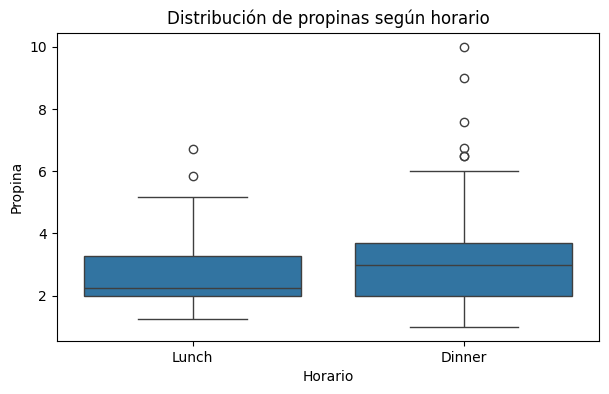

In [ ]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="time",
    y="tip"
)

plt.title("Distribución de propinas según horario")
plt.xlabel("Horario")
plt.ylabel("Propina")

plt.show()

El boxplot compara la distribución de las propinas entre `Lunch` y `Dinner`. La mediana de `Dinner` aparece más alta que la mediana de `Lunch`. También se observa que la caja de `Dinner` está algo más extendida, lo que indica mayor dispersión en la mitad central de las propinas. En ambos horarios aparecen posibles valores extremos hacia valores altos.

* En `Lunch` hay algunos valores por encima de 5.
* En `Dinner` aparecen más valores altos, incluyendo propinas cercanas a 9 y 10.

Esta comparación sugiere que, en este dataset, las propinas de `Dinner` tienden a ser un poco más altas y más variables que las propinas de `Lunch`.

De todos modos, esta lectura debe hacerse recordando que `Dinner` tiene muchos más registros que `Lunch`.

## Comparar con más de una categoría

Hasta ahora comparamos una variable numérica usando una sola variable categórica.

Por ejemplo:

`total_bill` según `time`;

`total_bill` según `day`;

`tip` según `time`.

Ahora vamos a preparar una comparación un poco más detallada. Queremos observar la distribución de `total_bill` según el día, pero separando también por horario.

Antes de graficar, conviene revisar cuántos registros hay en cada combinación de día y horario.

In [ ]:
cuentas_dia_horario = pd.crosstab(
    df["day"],
    df["time"]
)

cuentas_dia_horario = cuentas_dia_horario.loc[orden_dias]

cuentas_dia_horario

time,Lunch,Dinner
day,,
Thur,61,1
Fri,7,12
Sat,0,87
Sun,0,76


La tabla muestra cuántas cuentas hay en cada combinación de día y horario. La distribución no es pareja:

- `Thur` tiene casi todos sus registros en `Lunch` y solo 1 cuenta en `Dinner`;
- `Fri` tiene pocos registros en ambos horarios, con 7 en `Lunch` y 12 en `Dinner`;
- `Sat` tiene registros solo en `Dinner`;
- `Sun` tiene registros solo en `Dinner`.

Esto es muy importante.

Si hacemos un gráfico separando por día y horario, no todos los grupos estarán igualmente representados. Por ejemplo, no tendría sentido comparar seriamente el `Dinner` de `Thur` con otros grupos, porque tiene una sola cuenta. Tampoco aparecerán valores de `Lunch` para `Sat` y `Sun`, porque no hay registros en esas combinaciones.

Esta tabla nos recuerda que un gráfico puede mostrar diferencias, pero siempre tenemos que revisar cuántos datos hay detrás de cada comparación.

## Boxplot con día y horario

Ahora vamos a construir un boxplot de `total_bill` según el día, separando además por horario. Para eso vamos a usar el argumento `hue`.

En este caso:

- `x="day"` ubica los días en el eje horizontal;
- `y="total_bill"` muestra el importe total de la cuenta;
- `hue="time"` separa cada día según `Lunch` y `Dinner`.

Este gráfico nos va a permitir comparar más de una categoría al mismo tiempo, pero debemos leerlo junto con la tabla anterior.

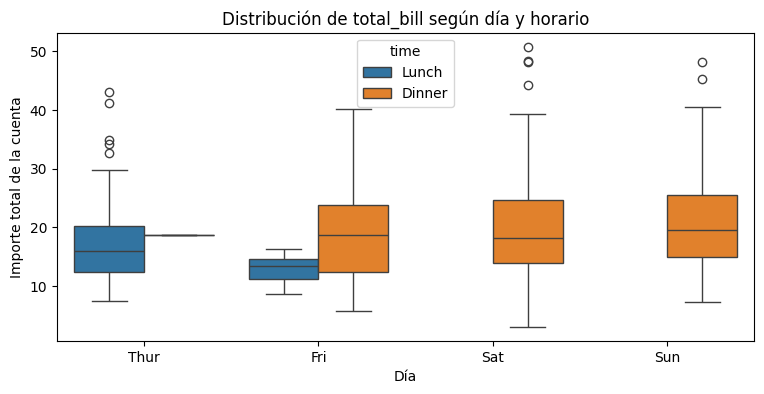

In [ ]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=df,
    x="day",
    y="total_bill",
    hue="time",
    order=orden_dias
)

plt.title("Distribución de total_bill según día y horario")
plt.xlabel("Día")
plt.ylabel("Importe total de la cuenta")

plt.show()

El boxplot compara `total_bill` según el día y, además, separa cada día por horario. La lectura debe hacerse junto con la tabla anterior, porque no todas las combinaciones tienen la misma cantidad de datos.

En `Thur`, casi todos los registros corresponden a `Lunch`. La caja azul representa bien ese grupo porque tiene 61 cuentas. En cambio, el valor de `Dinner` para `Thur` corresponde a una sola cuenta, por eso no conviene interpretarlo como una distribución.

En `Fri`, aparecen datos tanto para `Lunch` como para `Dinner`, pero ambos grupos tienen pocos registros. La comparación puede observarse, pero con cautela.

En `Sat` y `Sun`, solo aparecen registros de `Dinner`. Por eso no hay cajas de `Lunch` para esos días.

El gráfico muestra que las cuentas de `Dinner` en `Sat` y `Sun` tienden a ubicarse en importes más altos que los almuerzos de `Thur` y `Fri`.

Pero la conclusión más importante no es solo esa diferencia, sino la forma de leer el gráfico: cuando usamos más de una categoría, siempre tenemos que revisar cuántos datos hay en cada combinación.

## Leer `hue` en un boxplot

En este gráfico volvimos a usar el argumento `hue`.

La instrucción principal fue:

```python
sns.boxplot(
    data=df,
    x="day",
    y="total_bill",
    hue="time",
    order=orden_dias
)
```

El argumento `x="day"` ubica los días en el eje horizontal.

El argumento `y="total_bill"` indica que queremos comparar los importes de las cuentas.

El argumento `hue="time"` divide cada día según el horario: `Lunch` y `Dinner`.

Por eso, dentro de cada día, Seaborn intenta mostrar una distribución para cada horario.

Si una combinación no tiene registros, no aparece una caja.

Si una combinación tiene muy pocos registros, el gráfico puede mostrar algo, pero la interpretación debe ser cuidadosa.


## Ver los datos individuales

El boxplot resume una distribución, pero no muestra cada dato de manera individual. Cuando algunos grupos tienen pocos registros, puede ser útil ver los puntos originales. Para eso podemos usar un gráfico de puntos con `stripplot`.

Este gráfico no reemplaza al boxplot, pero nos ayuda a ver cuántas observaciones hay en cada grupo y cómo se ubican.

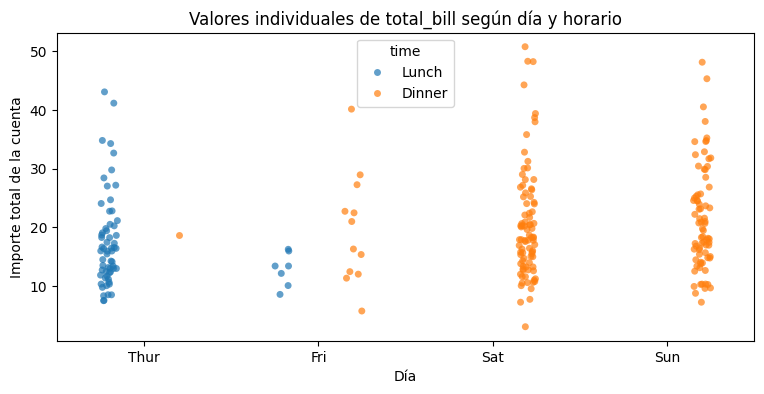

In [ ]:
plt.figure(figsize=(9, 4))

sns.stripplot(
    data=df,
    x="day",
    y="total_bill",
    hue="time",
    order=orden_dias,
    dodge=True,
    jitter=True,
    alpha=0.7
)

plt.title("Valores individuales de total_bill según día y horario")
plt.xlabel("Día")
plt.ylabel("Importe total de la cuenta")

plt.show()

El gráfico de puntos muestra los valores individuales de `total_bill` según día y horario. Cada punto representa una cuenta.

Esta visualización permite ver con más claridad cuántos datos hay detrás de cada grupo.

Por ejemplo:

- en `Thur` se observa una gran concentración de puntos azules, correspondientes a `Lunch`;
- en `Thur` aparece un solo punto naranja, correspondiente a `Dinner`;
- en `Fri` hay pocos puntos tanto en `Lunch` como en `Dinner`;
- en `Sat` y `Sun` aparecen solamente puntos de `Dinner`;
- no hay puntos de `Lunch` en `Sat` ni en `Sun`, porque no existen registros para esas combinaciones.

Este gráfico refuerza una idea importante: cuando usamos un boxplot, vemos un resumen de la distribución, pero no vemos directamente la cantidad de observaciones. El `stripplot` nos ayuda a recuperar esa información visualmente.

Por eso, cuando los grupos tienen pocos datos o cantidades muy diferentes, puede ser útil combinar gráficos de resumen con gráficos que muestren los datos individuales.

## Cómo leer `stripplot`

En la celda anterior usamos `sns.stripplot()`.

La instrucción principal fue:

```python
sns.stripplot(
    data=df,
    x="day",
    y="total_bill",
    hue="time",
    order=orden_dias,
    dodge=True,
    jitter=True,
    alpha=0.7
)
```

El argumento `x="day"` ubica los días en el eje horizontal.

El argumento `y="total_bill"` ubica el importe de cada cuenta en el eje vertical.

El argumento `hue="time"` colorea los puntos según el horario.

El argumento `dodge=True` separa visualmente los puntos de `Lunch` y `Dinner` dentro de cada día.

El argumento `jitter=True` agrega una pequeña separación horizontal entre puntos para que no queden todos encimados.

El argumento `alpha=0.7` hace que los puntos sean un poco transparentes. Esto ayuda a leer zonas donde hay muchos puntos cercanos.

## Cierre del capítulo

En este capítulo comparamos distribuciones de variables numéricas entre grupos:

* Primero analizamos `total_bill` según `time`.
* Después comparamos `total_bill` según `day`.
* Luego analizamos `tip` según `time`.
* Finalmente combinamos dos categorías: `day` y `time`.

En todos los casos seguimos una idea central: no alcanza con mirar si un grupo tiene valores más altos que otro. También necesitamos observar:

* la mediana;
* la dispersión;
* los posibles valores extremos;
* y la cantidad de datos disponible en cada grupo.

Esto es especialmente importante cuando algunos grupos tienen muchos registros y otros tienen muy pocos.

Usamos principalmente boxplots para comparar variables numéricas según categorías. También usamos gráficos de barras para revisar la cantidad de registros por grupo, y un `stripplot` para visualizar los datos individuales.

La idea más importante fue que una comparación entre grupos debe leerse con cuidado. Un gráfico puede sugerir diferencias, pero esas diferencias deben interpretarse teniendo en cuenta cuántos datos hay detrás de cada grupo.

En el próximo capítulo vamos a seguir trabajando con visualizaciones, pero avanzando hacia gráficos que permiten observar relaciones entre variables numéricas.